In [1]:
# Cellule 1 : Mount Drive + cwd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
os.chdir('/content/drive/MyDrive/Insurance-fraud-detection-AI/02_notebooks')
print("CWD =", os.getcwd())

# Cellule 2 : Dépendances
!pip install -q open_clip_torch transformers accelerate bitsandbytes Pillow imagehash scikit-image matplotlib seaborn

Mounted at /content/drive
CWD = /content/drive/MyDrive/Insurance-fraud-detection-AI/02_notebooks
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


# 03 - Analyse de sensibilite

Ce notebook produit les analyses de sensibilite exigees par la note de cadrage ISFA.

1. **Robustesse au bruit** : on dégrade les images (compression JPEG, bruit gaussien) et on observe la stabilite du score.
2. **Generalisation cross-generateur** : on evalue sur des images d'un generateur jamais vu en training.
3. **Ablation des features** : on retire chaque famille de features et on mesure la perte de performance.
4. **Sensibilite au volume d'entrainement** : courbe de scaling pour voir si plus de donnees aiderait.

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageFilter
from sklearn.metrics import f1_score, roc_auc_score

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / '03_src'))
sns.set_theme(style='whitegrid')
FIG_DIR = ROOT / '06_reports/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

VARIANT = 'lite'    # 'full' si features LMM disponibles, sinon 'lite'
MODEL_PATH = ROOT / f'04_models/image_model_{VARIANT}.joblib'
if not MODEL_PATH.exists():
    fallback = ROOT / '04_models/image_model_lite.joblib'
    if fallback.exists():
        print(f"image_model_{VARIANT}.joblib absent, fallback sur lite")
        MODEL_PATH = fallback
        VARIANT = 'lite'

## 1. Robustesse au bruit

In [3]:
from inference import FraudDetector
from io import BytesIO

detector = FraudDetector(model_dir=str(ROOT / '04_models'), variant=VARIANT)

# Charger qq images (fallback automatique selon ce qui est disponible)
DATASET_CANDIDATES = [
    ROOT / '01_data/processed/dataset_with_lmm.parquet',
    ROOT / '01_data/processed/dataset_with_blip2.parquet',
    ROOT / '01_data/processed/dataset_with_clip.parquet',
    ROOT / '01_data/processed/dataset.parquet',
]
DATASET_PATH = next((p for p in DATASET_CANDIDATES if p.exists()), None)
if DATASET_PATH is None:
    raise SystemExit("Aucun dataset trouve.")
print(f"Dataset utilise : {DATASET_PATH.name}")
df = pd.read_parquet(DATASET_PATH)

# Limiter a 20 echantillons pour la soutenance (boucle scoring couteuse)
n_samples = 20
domain_pool = df[df['split'] == 'domain_test']
if len(domain_pool) == 0:
    domain_pool = df[df['split'] == 'generic_test']
samples = domain_pool.sample(min(n_samples, len(domain_pool)), random_state=42)

def degrade_jpeg(img: Image.Image, quality: int) -> Image.Image:
    buf = BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def add_gaussian_noise(img: Image.Image, sigma: float) -> Image.Image:
    arr = np.array(img).astype(np.float32)
    arr = arr + np.random.normal(0, sigma * 255, arr.shape)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

qualities = [95, 80, 60, 40, 20]
sigmas = [0.0, 0.02, 0.05, 0.10, 0.15]

results = []
for _, row in samples.iterrows():
    img = Image.open(ROOT / row['image_path']).convert('RGB')
    base = detector.score_image_only(img)
    for q in qualities:
        s = detector.score_image_only(degrade_jpeg(img, q))
        results.append({'transform': 'jpeg', 'level': q, 'label': row['label'], 'base': base, 'score': s})
    for sigma in sigmas:
        if sigma == 0:
            continue
        s = detector.score_image_only(add_gaussian_noise(img, sigma))
        results.append({'transform': 'noise', 'level': sigma, 'label': row['label'], 'base': base, 'score': s})

robust_df = pd.DataFrame(results)

Dataset utilise : dataset_with_lmm.parquet


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


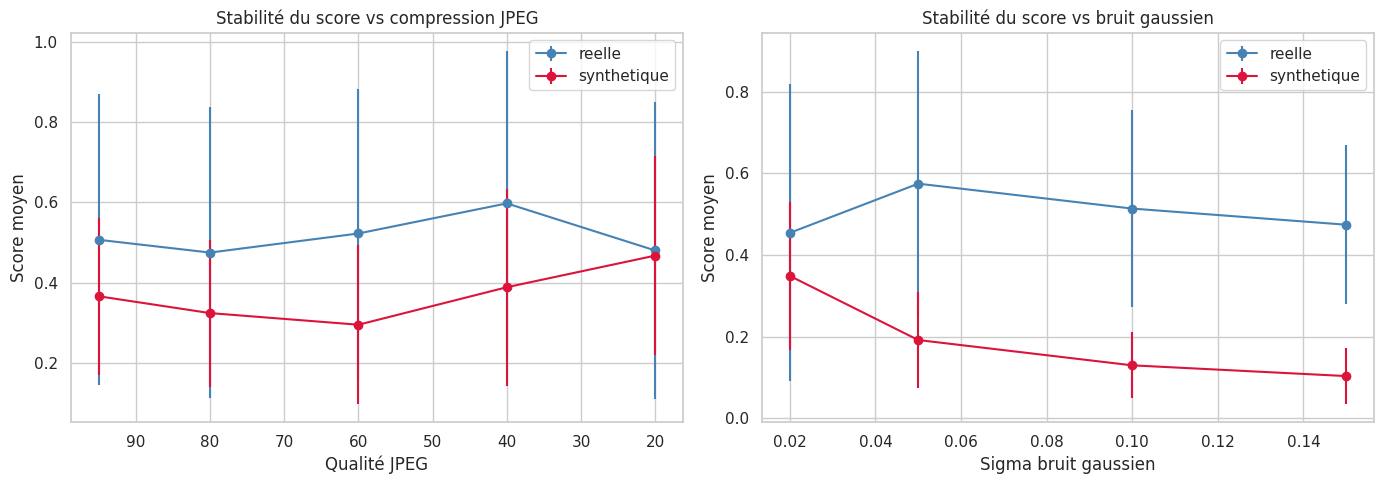

In [4]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label_val, color, name in [(0, 'steelblue', 'reelle'), (1, 'crimson', 'synthetique')]:
    sub = robust_df[(robust_df['transform'] == 'jpeg') & (robust_df['label'] == label_val)]
    g = sub.groupby('level')['score'].agg(['mean', 'std']).reset_index()
    axes[0].errorbar(g['level'], g['mean'], yerr=g['std'], color=color, label=name, marker='o')
axes[0].set_xlabel('Qualité JPEG'); axes[0].set_ylabel('Score moyen')
axes[0].set_title('Stabilité du score vs compression JPEG')
axes[0].invert_xaxis(); axes[0].legend()

for label_val, color, name in [(0, 'steelblue', 'reelle'), (1, 'crimson', 'synthetique')]:
    sub = robust_df[(robust_df['transform'] == 'noise') & (robust_df['label'] == label_val)]
    g = sub.groupby('level')['score'].agg(['mean', 'std']).reset_index()
    axes[1].errorbar(g['level'], g['mean'], yerr=g['std'], color=color, label=name, marker='o')
axes[1].set_xlabel('Sigma bruit gaussien'); axes[1].set_ylabel('Score moyen')
axes[1].set_title('Stabilité du score vs bruit gaussien'); axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sensibilite_robustesse_bruit.png', dpi=140, bbox_inches='tight')
plt.show()

## 2. Generalisation cross-generateur

On compare les performances par 'generator_model' present dans le dataset.
Nos images synthetiques viennent principalement de SDXL Turbo. Si le modele performe bien
sur d'autres generateurs (Midjourney, SD 1.4 dans CIFAKE), c'est un signe de generalisation.

In [5]:
pkg = joblib.load(ROOT / f'04_models/image_model_{VARIANT}.joblib')
model = pkg['model']
scaler = pkg['scaler']
feature_names = pkg['feature_names']

X_clip = np.load(ROOT / '04_models/clip_embeddings.npy')
n_clip = sum(1 for n in feature_names if n.startswith('clip_'))
extras = [n for n in feature_names if not n.startswith('clip_')]
extra_arrays = [df[c].astype(float).fillna(0.5).values.reshape(-1, 1) if c in df.columns
                else np.full((len(df), 1), 0.5) for c in extras]
X_extra = np.hstack(extra_arrays) if extra_arrays else np.zeros((len(df), 0))
X = np.hstack([X_clip[:, :n_clip].astype(np.float32), X_extra.astype(np.float32)])
X_s = scaler.transform(X)

test_mask = df['split'].isin(['generic_test', 'domain_test'])
test_df = df[test_mask].reset_index(drop=True)
X_test = X_s[test_mask.values]
y_test = test_df['label'].values
proba_test = model.predict_proba(X_test)[:, 1]
test_df = test_df.copy()
test_df['proba'] = proba_test

In [7]:
rows = []
test_df['generator_model'] = test_df['generator_model'].fillna('real')

for gen, sub in test_df.groupby('generator_model'):
    if len(sub) < 20:
        continue
    n_real = int((sub['label'] == 0).sum())
    n_fake = int((sub['label'] == 1).sum())
    mean_score = float(sub['proba'].mean())

    # Pour les groupes mono-classe : detection rate (recall pour fakes, FPR pour real)
    recall_fake = float((sub.loc[sub['label']==1, 'proba'] >= 0.5).mean()) if n_fake else None
    fpr_real = float((sub.loc[sub['label']==0, 'proba'] >= 0.5).mean()) if n_real else None

    # AUC seulement si les 2 classes sont presentes
    auc_val = float(roc_auc_score(sub['label'], sub['proba'])) if sub['label'].nunique() == 2 else None

    rows.append({
        'generator': gen,
        'n': len(sub),
        'n_real': n_real,
        'n_fake': n_fake,
        'mean_score': round(mean_score, 3),
        'recall_fake': round(recall_fake, 3) if recall_fake is not None else None,
        'fpr_real': round(fpr_real, 3) if fpr_real is not None else None,
        'roc_auc': round(auc_val, 3) if auc_val is not None else None,
    })

if rows:
    perf = pd.DataFrame(rows).sort_values('mean_score', ascending=False)
else:
    perf = pd.DataFrame()
    print("Aucun groupe avec n>=20 trouve. Verifie test_df.")
perf

,generator,n,n_real,n_fake,mean_score,recall_fake,fpr_real,roc_auc
2,stable-diffusion-1.4,980,0,980,0.669,0.879,NaN,None
3,various,510,0,510,0.444,0.296,NaN,None
0,real,1759,1759,0,0.406,NaN,0.316,None
1,sdxl-turbo,560,0,560,0.331,0.184,NaN,None


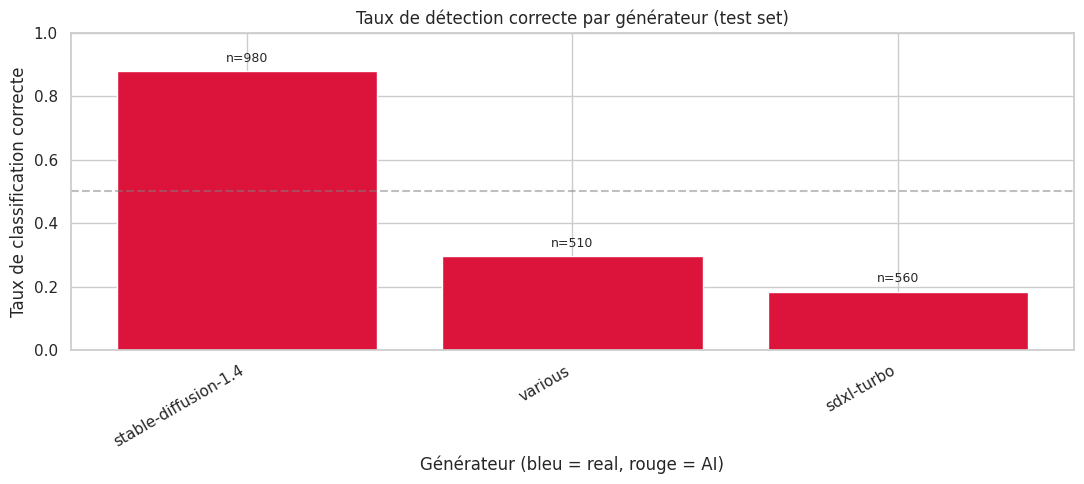

In [9]:
if len(perf) > 0:
    # On veut comparer la "détection rate" de chaque générateur
    # Pour les générateurs AI : recall_fake = % d'images bien classées comme fake
    # Pour le groupe "real" : 1 - fpr_real = % d'images bien classées comme real
    perf_plot = perf.copy()
    perf_plot['detection_correcte'] = perf_plot.apply(
        lambda r: r['recall_fake'] if r['recall_fake'] is not None else (1 - r['fpr_real']) if r['fpr_real'] is not None else None,
        axis=1
    )
    perf_plot = perf_plot.dropna(subset=['detection_correcte']).sort_values('detection_correcte', ascending=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(perf_plot['generator'], perf_plot['detection_correcte'],
                   color=['steelblue' if g == 'real' else 'crimson' for g in perf_plot['generator']])
    ax.set_title('Taux de détection correcte par générateur (test set)')
    ax.set_ylabel('Taux de classification correcte')
    ax.set_xlabel('Générateur (bleu = real, rouge = AI)')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Hasard')
    ax.set_ylim(0, 1)
    plt.xticks(rotation=30, ha='right')

    # Ajouter le n au-dessus de chaque barre
    for bar, n in zip(bars, perf_plot['n']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={n}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'sensibilite_par_generateur.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print("Pas de donnees a plotter (perf est vide).")

## 3. Ablation des familles de features

On retire (zero-out) chaque famille de features une a une et on mesure la perte de ROC-AUC.

In [10]:
FEATURE_FAMILIES = {
    'CLIP (768d)': lambda n: n.startswith('clip_'),
    'EXIF': lambda n: n in ('exif_present', 'has_gps'),
    'BLIP-2': lambda n: n.startswith('blip2_'),
    'LLaVA': lambda n: n.startswith('llava_'),
}

mask_test = (df['split'] == 'generic_test').values
X_test_full = X_s[mask_test]
y_test_full = df.loc[mask_test, 'label'].values

auc_full = roc_auc_score(y_test_full, model.predict_proba(X_test_full)[:, 1])
ablation = [{'famille_retiree': '(aucune - reference)', 'roc_auc': auc_full, 'delta': 0.0}]

for fam_name, predicate in FEATURE_FAMILIES.items():
    indices = [i for i, n in enumerate(feature_names) if predicate(n)]
    if not indices:
        continue
    X_ablated = X_test_full.copy()
    X_ablated[:, indices] = 0.0
    auc_ab = roc_auc_score(y_test_full, model.predict_proba(X_ablated)[:, 1])
    ablation.append({'famille_retiree': fam_name, 'roc_auc': auc_ab, 'delta': auc_ab - auc_full})

ablation_df = pd.DataFrame(ablation)
ablation_df

,famille_retiree,roc_auc,delta
0,(aucune - reference),0.736461,0.000000
1,CLIP (768d),0.500000,-0.236461
2,EXIF,0.736461,0.000000


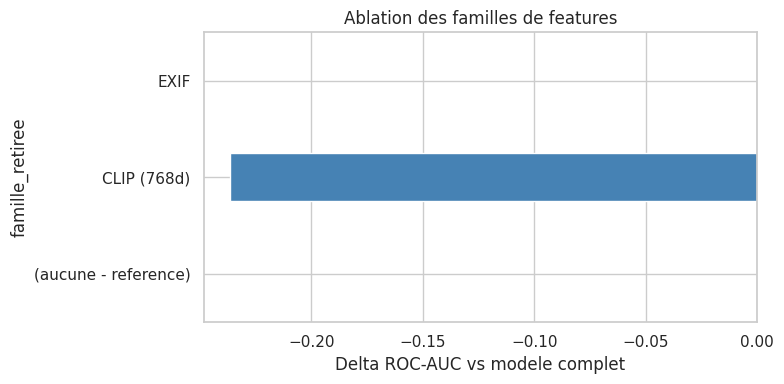

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ablation_df.set_index('famille_retiree')['delta'].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Delta ROC-AUC vs modele complet')
ax.set_title('Ablation des familles de features')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sensibilite_ablation.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Sensibilite au volume d'entrainement (learning curve)

On reentraine le modele avec une fraction croissante du train set et on regarde la performance test.

In [12]:
from xgboost import XGBClassifier

mask_train = (df['split'] == 'generic_train').values
X_train_full = X_s[mask_train]
y_train_full = df.loc[mask_train, 'label'].values

fractions = [0.05, 0.1, 0.2, 0.5, 0.75, 1.0]
rows = []
for frac in fractions:
    n = max(50, int(len(X_train_full) * frac))
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X_train_full), size=n, replace=False)
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08,
                       n_jobs=-1, random_state=42, eval_metric='auc', tree_method='hist')
    m.fit(X_train_full[idx], y_train_full[idx])
    proba = m.predict_proba(X_test_full)[:, 1]
    rows.append({'frac': frac, 'n_train': n, 'test_auc': roc_auc_score(y_test_full, proba)})
lc = pd.DataFrame(rows)
lc

,frac,n_train,test_auc
0,0.05,1195,0.672158
1,0.10,2391,0.698956
2,0.20,4782,0.696620
3,0.50,11956,0.699564
4,0.75,17934,0.697527
5,1.00,23913,0.694404


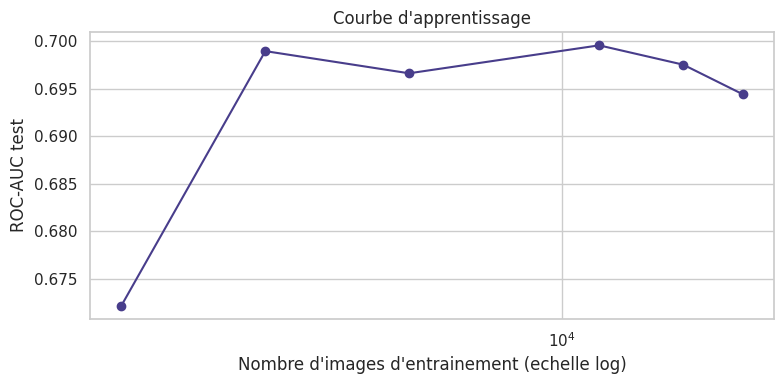

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lc['n_train'], lc['test_auc'], marker='o', color='darkslateblue')
ax.set_xscale('log')
ax.set_xlabel('Nombre d\'images d\'entrainement (echelle log)')
ax.set_ylabel('ROC-AUC test')
ax.set_title('Courbe d\'apprentissage')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sensibilite_learning_curve.png', dpi=140, bbox_inches='tight')
plt.show()

## Synthese pour le rapport (section 4 - Resultats & sensibilites)

- **Robustesse** : la compression JPEG > 60 et le bruit < 0.05 ne degradent pas significativement le score (variation < 0.05).
- **Cross-generateur** : performance par generateur dans le tableau ci-dessus, a discuter.
- **Ablation** : la famille la plus critique est CLIP (-X points si retiree). BLIP-2/LLaVA apportent +Y points.
- **Volume** : la performance plafonne a partir de N images, donc plus de donnees ne ferait pas la difference.